In [1]:
import os
import re
from pathlib import Path
import pandas as pd
import numpy as np

In [2]:
base_url = "https://raw.githubusercontent.com/cdd369/CPSC5440/main/assignment_1/"

files = {
    0: base_url + "english.txt",
    2: base_url + "french.txt",
    1: base_url + "german.txt",
    # 3: base_url + "spanish.txt"
}

data = []

for label, url in files.items():
    try:
        df_temp = pd.read_csv(
            url,
            header=None,
            names=["word"],
            encoding="utf-8"
        )
    except UnicodeDecodeError:
        df_temp = pd.read_csv(
            url,
            header=None,
            names=["word"],
            encoding="latin-1"
        )
# for label, url in files.items():
#     df_temp = pd.read_csv(
#         url,
#         header=None,
#         names=["word"],
#         encoding="latin-1"
#     )

    df_temp["label"] = label
    data.append(df_temp)

df = pd.concat(data, ignore_index=True)

print(df.head())

       word  label
0         a      0
1        aa      0
2       aaa      0
3    aachen      0
4  aardvark      0


In [3]:
df_5 = df[df["word"].str.len() == 5].copy()

print("Total 5-letter words:", len(df_5))
df_5.head()

Total 5-letter words: 21481


,word,label
9,aaron,0
16,ababa,0
18,abaca,0
20,abaci,0
21,aback,0


**One-Hot Vector Encoding**

**Character n-gram features**
This works extremely well because languages have distinct letter patterns:

English → th, sh

German → sch, ei

French → eau, ette

Spanish → ll, que, ñ

Even with single words, n-grams can achieve very high accuracy.

In [4]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    analyzer="char",
    ngram_range=(2,3)
)

X_ngm = vectorizer.fit_transform(df_5["word"])
y_ngm = df_5["label"].values
print(df_5[:1])
print(X_ngm.shape)
print(X_ngm[:1])
print(y_ngm[:1])

    word  label
9  aaron      0
(21481, 7441)
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 7 stored elements and shape (1, 7441)>
  Coords	Values
  (0, 21)	1
  (0, 312)	1
  (0, 4864)	1
  (0, 4150)	1
  (0, 31)	1
  (0, 325)	1
  (0, 4878)	1
[0]


**Creating Tranining and Testing Data**

In [5]:
from sklearn.model_selection import train_test_split

# ----- N-gram dataset -----
X_train_ngram, X_test_ngram, y_train_ngram, y_test_ngram = train_test_split(
    X_ngm,
    y_ngm,
    test_size=0.2,
    random_state=42
)

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [12]:
knn_model = KNeighborsClassifier(
    n_neighbors=15,
    weights='uniform', # uniform:best or distance
    metric='minkowski',
    p=2,
    algorithm='auto',
    leaf_size=10
)
knn_model.fit(X_train_ngram, y_train_ngram)
y_pred_knn = knn_model.predict(X_test_ngram)
knn_acc = accuracy_score(y_test_ngram, y_pred_knn)
print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.6565045380498021


In [8]:
#svm_model = svm.SVC(kernel='rbf', C=10, gamma = 0.01) #, gamma='scale',random_state=42 #68.7
svm_model = svm.SVC(kernel='rbf', C=10, gamma=0.001)
svm_model.fit(X_train_ngram, y_train_ngram)
y_pred_svm = svm_model.predict(X_test_ngram)
svm_acc = accuracy_score(y_test_ngram, y_pred_svm)
print("SVM Accuracy:", svm_acc)


SVM Accuracy: 0.6802420293227833


In [14]:
mlp_nn = MLPClassifier(
    hidden_layer_sizes=(100,50),
    # activation='relu',
    # solver='adam',
    # alpha=0.01,
    # learning_rate_init=0.001,
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=25
)
# mlp_nn = MLPClassifier(
#     hidden_layer_sizes=(256,128),
#     max_iter=10000,
#     random_state=42,
#     early_stopping=True,
#     n_iter_no_change=25
# )
mlp_nn.fit(X_train_ngram, y_train_ngram)
y_pred_mlp = mlp_nn.predict(X_test_ngram)
mlp_acc = accuracy_score(y_test_ngram, y_pred_mlp)
print("MLP Accuracy:", mlp_acc)

MLP Accuracy: 0.7228298813125437


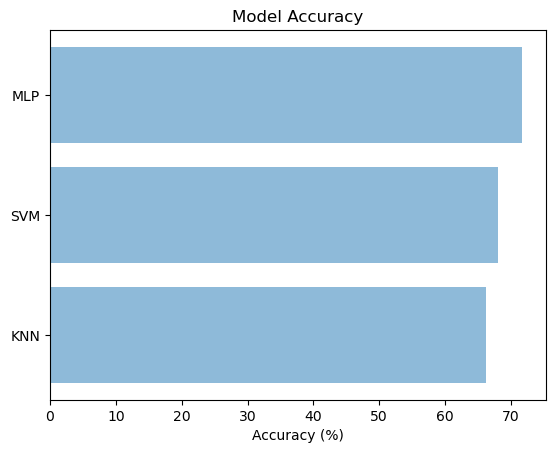

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Label text for each graph
labels = ("KNN", "SVM", "MLP")

# Numbers that you want the bars to represent
value = [knn_acc, svm_acc, mlp_acc]
value_per = [val*100 for val in value]
# Title of the plot
plt.title("Model Accuracy")

# Label for the x values of the bar graph
plt.xlabel("Accuracy (%)")

# Drawing the bar graph
y_pos = np.arange(len(labels))
plt.barh(y_pos, value_per, align="center", alpha=0.5)
plt.yticks(y_pos, labels)

# Display the graph
plt.show()